# Examen Final - Procesamiento de Imágenes en Python

Este notebook implementa procesamiento de imágenes sobre una imagen RGB de un animal en vía de extinción (mapache), incluyendo:
- Filtros básicos (suavizado y realce de bordes)
- Visualización de canales de color (R, G, B)
- Operaciones morfológicas (erosión y dilatación)
- Generación de animación GIF


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from PIL import Image
import imageio
import os

# Configurar matplotlib para mejor visualización
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Crear carpeta para GIFs si no existe
os.makedirs('gifs', exist_ok=True)


## 1. Carga y Visualización de la Imagen Original

Cargamos una imagen RGB de un mapache (animal en vía de extinción) y la visualizamos.


Dimensiones de la imagen: (548, 787, 3)
Tipo de datos: uint8


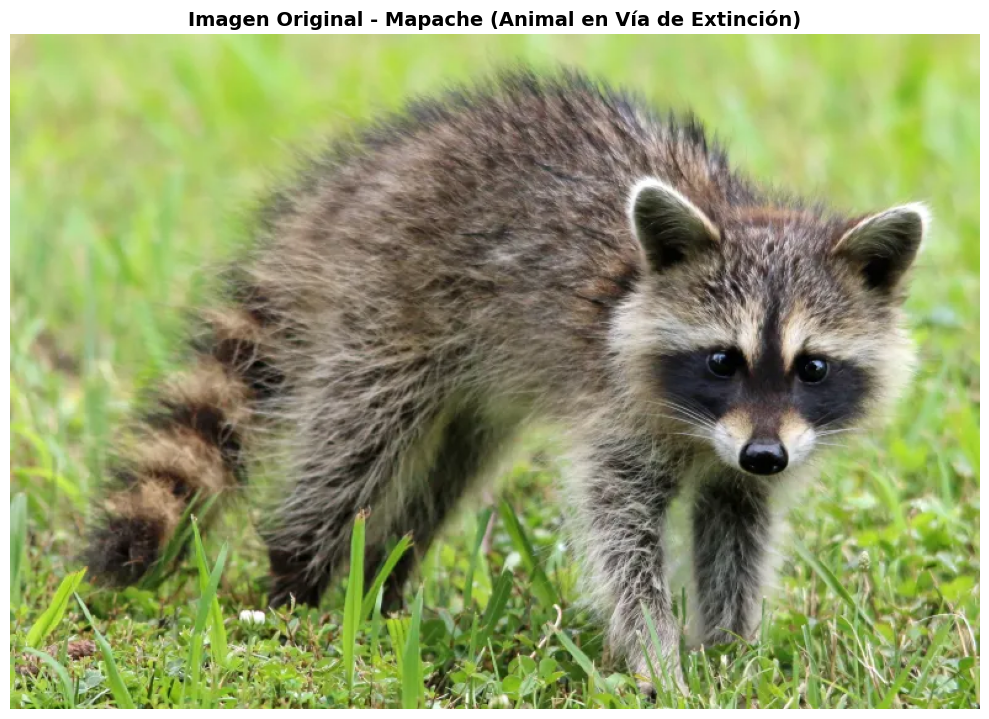

In [ ]:
# Cargar imagen
image_path = 'data/animal.webp'

# Leer imagen con OpenCV (BGR)
img_bgr = cv2.imread(image_path)

# Convertir de BGR a RGB para visualización
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Verificar que la imagen se cargó correctamente
if img_rgb is None:
    # Si OpenCV no puede leer webp, usar PIL
    pil_img = Image.open(image_path)
    img_rgb = np.array(pil_img.convert('RGB'))
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

print(f"Dimensiones de la imagen: {img_rgb.shape}")
print(f"Tipo de datos: {img_rgb.dtype}")

# Visualizar imagen original
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title('Imagen Original - Mapache (Animal en Vía de Extinción)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('gifs/01_imagen_original.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Imagen guardada: gifs/01_imagen_original.png")


## 2. Filtros Básicos

Aplicamos dos filtros a la imagen:
- **Suavizado/Desenfoque**: Filtro Gaussiano para reducir ruido y suavizar la imagen
- **Realce de Bordes**: Filtro Laplaciano para destacar los bordes y detalles


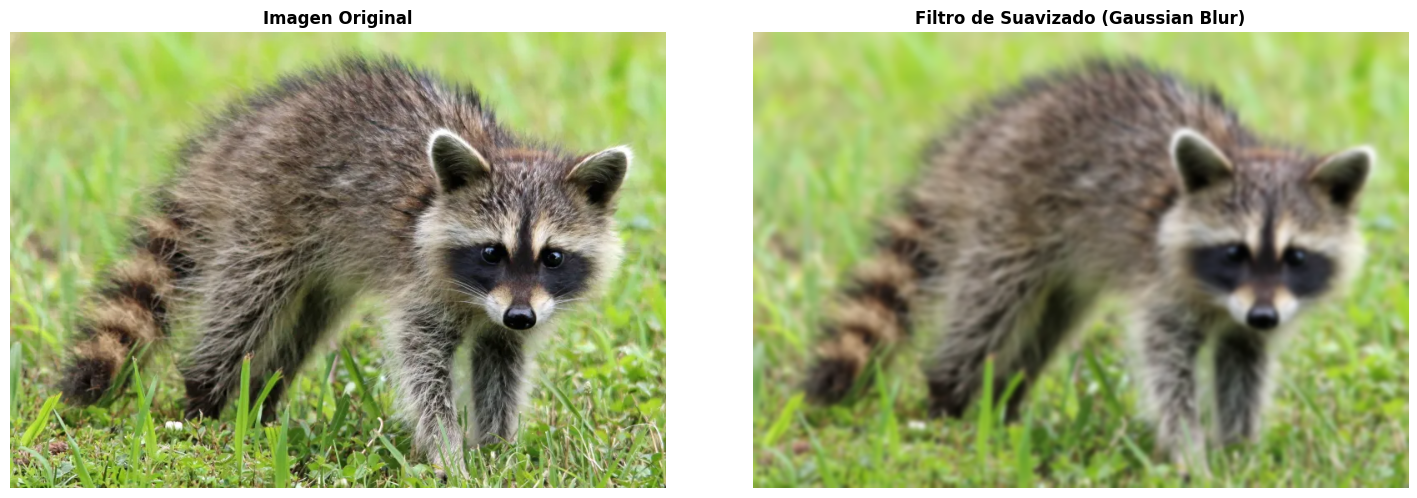


Comentario sobre el efecto visual del suavizado:
El filtro gaussiano reduce el ruido y suaviza los detalles finos de la imagen. 
Se observa una pérdida de nitidez en los bordes y texturas, creando un efecto 
de desenfoque uniforme. Los colores se mantienen pero con transiciones más suaves.



In [ ]:
# 2.1 Filtro de Suavizado (Gaussian Blur)
# Aplicar filtro gaussiano con kernel 15x15
blurred = cv2.GaussianBlur(img_rgb, (15, 15), 0)

# Visualizar resultado
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Imagen Original', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(blurred)
plt.title('Filtro de Suavizado (Gaussian Blur)', fontsize=12, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.savefig('gifs/02_filtro_suavizado.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Imagen guardada: gifs/02_filtro_suavizado.png")
print("""
Comentario sobre el efecto visual del suavizado:
El filtro gaussiano reduce el ruido y suaviza los detalles finos de la imagen. 
Se observa una pérdida de nitidez en los bordes y texturas, creando un efecto 
de desenfoque uniforme. Los colores se mantienen pero con transiciones más suaves.
""")


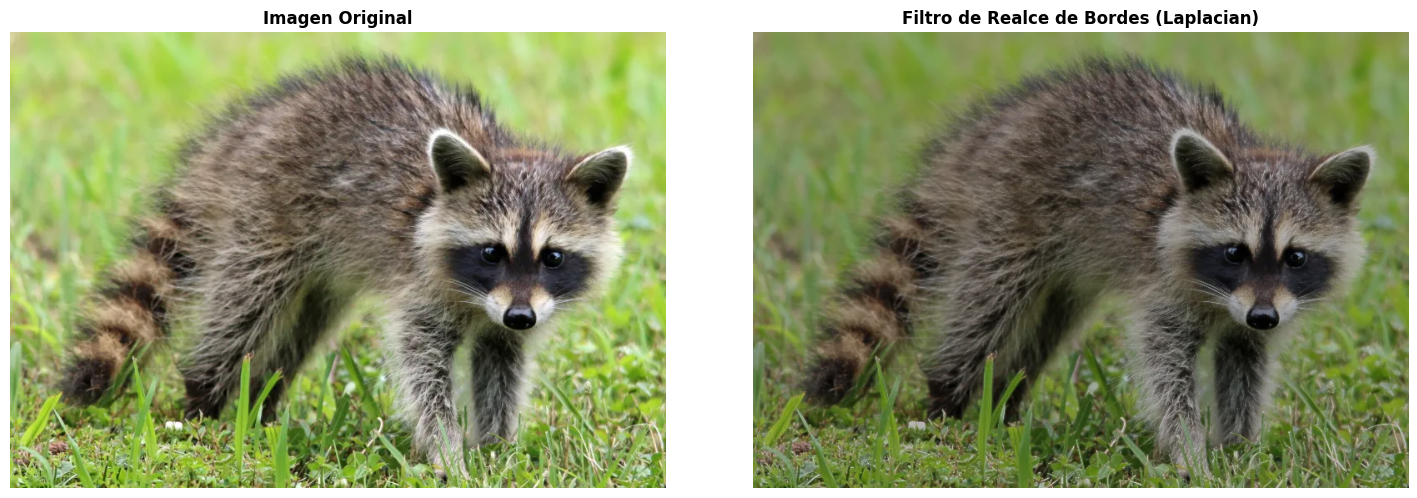


Comentario sobre el efecto visual del realce de bordes:
El filtro Laplaciano detecta y realza los cambios bruscos de intensidad (bordes).
Se observa un aumento en el contraste de los bordes, haciendo que los detalles 
como el pelaje, los ojos y las características faciales se vean más definidos y nítidos.
La imagen adquiere una apariencia más "aguda" y con mayor definición.



In [ ]:
# 2.2 Filtro de Realce de Bordes (Laplacian)
# Convertir a escala de grises para el filtro Laplaciano
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Aplicar filtro Laplaciano
laplacian = cv2.Laplacian(gray, cv2.CV_64F)

# Convertir a valores absolutos y normalizar
laplacian_abs = np.absolute(laplacian)
laplacian_normalized = np.uint8(255 * laplacian_abs / laplacian_abs.max())

# Combinar el realce de bordes con la imagen original
# Convertir laplacian a RGB para poder sumarlo
laplacian_rgb = cv2.cvtColor(laplacian_normalized, cv2.COLOR_GRAY2RGB)
sharpened = cv2.addWeighted(img_rgb, 0.7, laplacian_rgb, 0.3, 0)

# Visualizar resultado
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Imagen Original', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sharpened)
plt.title('Filtro de Realce de Bordes (Laplacian)', fontsize=12, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.savefig('gifs/03_filtro_realce_bordes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Imagen guardada: gifs/03_filtro_realce_bordes.png")
print("""
Comentario sobre el efecto visual del realce de bordes:
El filtro Laplaciano detecta y realza los cambios bruscos de intensidad (bordes).
Se observa un aumento en el contraste de los bordes, haciendo que los detalles 
como el pelaje, los ojos y las características faciales se vean más definidos y nítidos.
La imagen adquiere una apariencia más "aguda" y con mayor definición.
""")


## 3. Visualización de Canales de Color

Separamos la imagen en sus tres canales RGB y los visualizamos en escala de grises para analizar qué información aporta cada canal.


Rango Canal R: 0 - 255
Rango Canal G: 0 - 255
Rango Canal B: 0 - 255


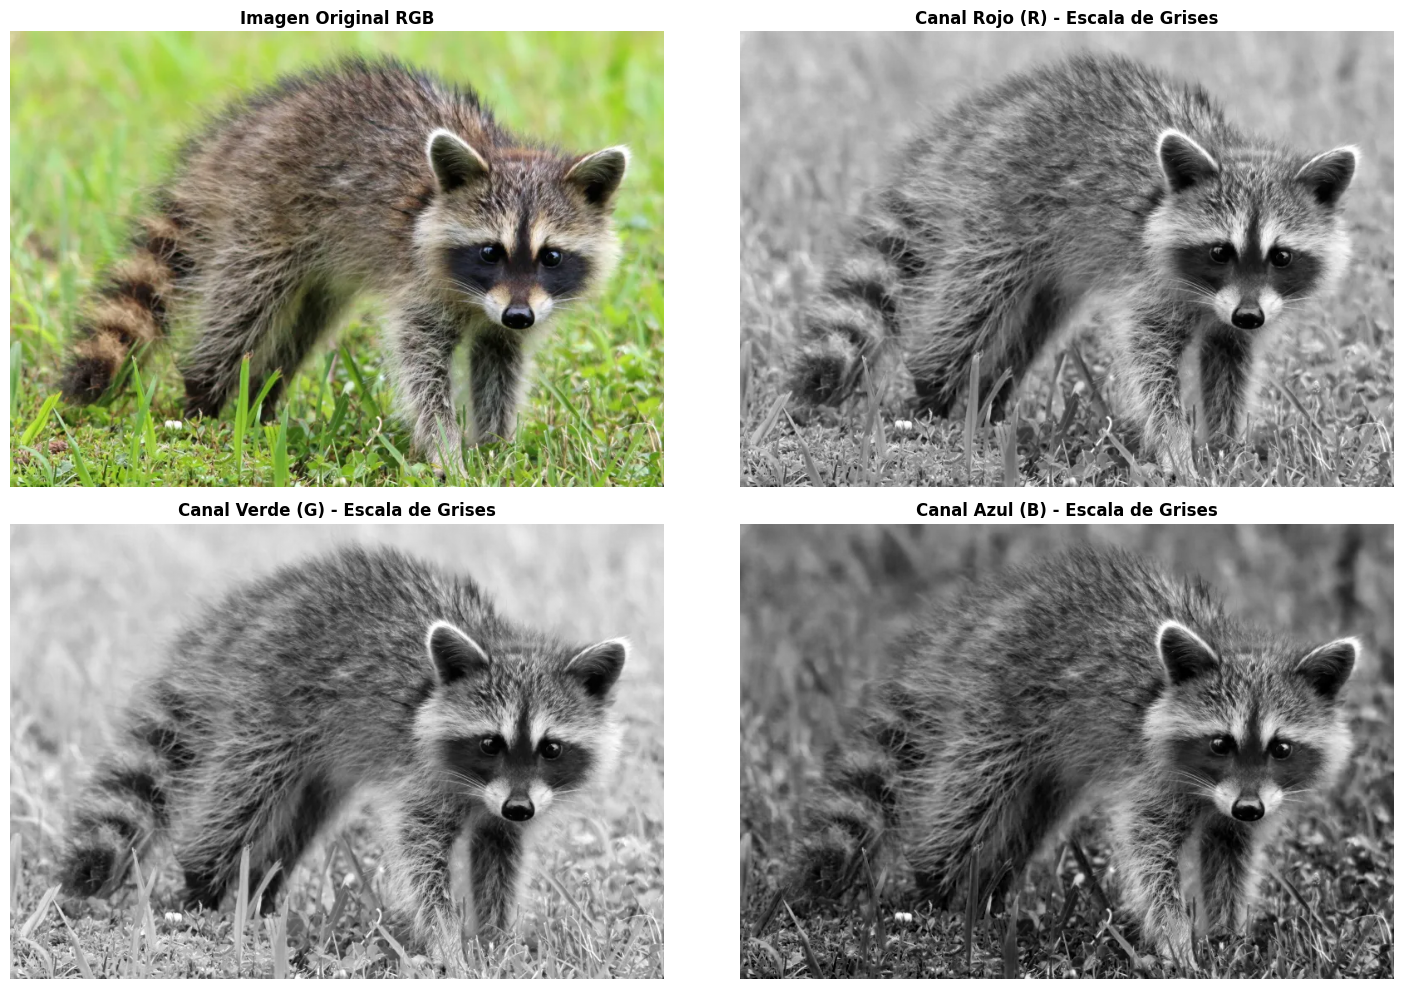


Análisis de los canales de color:

Canal Rojo (R): 
- Las áreas con tonos cálidos (pelaje marrón/rojizo del mapache) se ven más claras.
- Las zonas oscuras (ojos, nariz) se ven más oscuras.
- Este canal captura mejor la información de los tonos cálidos del animal.

Canal Verde (G):
- Generalmente muestra mejor contraste y detalle en imágenes naturales.
- Las áreas de vegetación y tonos verdes se verían más claras.
- En esta imagen, proporciona buena información general de luminosidad.

Canal Azul (B):
- Las áreas con tonos fríos se verían más claras.
- En esta imagen, las zonas más oscuras del pelaje y sombras se destacan.
- Suele tener menos información útil en imágenes de animales terrestres.



In [ ]:
# Separar canales RGB
r_channel = img_rgb[:, :, 0]
g_channel = img_rgb[:, :, 1]
b_channel = img_rgb[:, :, 2]

# Verificar que los canales tienen valores válidos
print(f"Rango Canal R: {r_channel.min()} - {r_channel.max()}")
print(f"Rango Canal G: {g_channel.min()} - {g_channel.max()}")
print(f"Rango Canal B: {b_channel.min()} - {b_channel.max()}")

# Visualizar canales
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Imagen Original RGB', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(r_channel, cmap='gray', vmin=0, vmax=255)
plt.title('Canal Rojo (R) - Escala de Grises', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(g_channel, cmap='gray', vmin=0, vmax=255)
plt.title('Canal Verde (G) - Escala de Grises', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(b_channel, cmap='gray', vmin=0, vmax=255)
plt.title('Canal Azul (B) - Escala de Grises', fontsize=12, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.savefig('gifs/04_canales_color.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Imagen guardada: gifs/04_canales_color.png")
print("""
Análisis de los canales de color:

Canal Rojo (R): 
- Las áreas con tonos cálidos (pelaje marrón/rojizo del mapache) se ven más claras.
- Las zonas oscuras (ojos, nariz) se ven más oscuras.
- Este canal captura mejor la información de los tonos cálidos del animal.

Canal Verde (G):
- Generalmente muestra mejor contraste y detalle en imágenes naturales.
- Las áreas de vegetación y tonos verdes se verían más claras.
- En esta imagen, proporciona buena información general de luminosidad.

Canal Azul (B):
- Las áreas con tonos fríos se verían más claras.
- En esta imagen, las zonas más oscuras del pelaje y sombras se destacan.
- Suele tener menos información útil en imágenes de animales terrestres.
""")


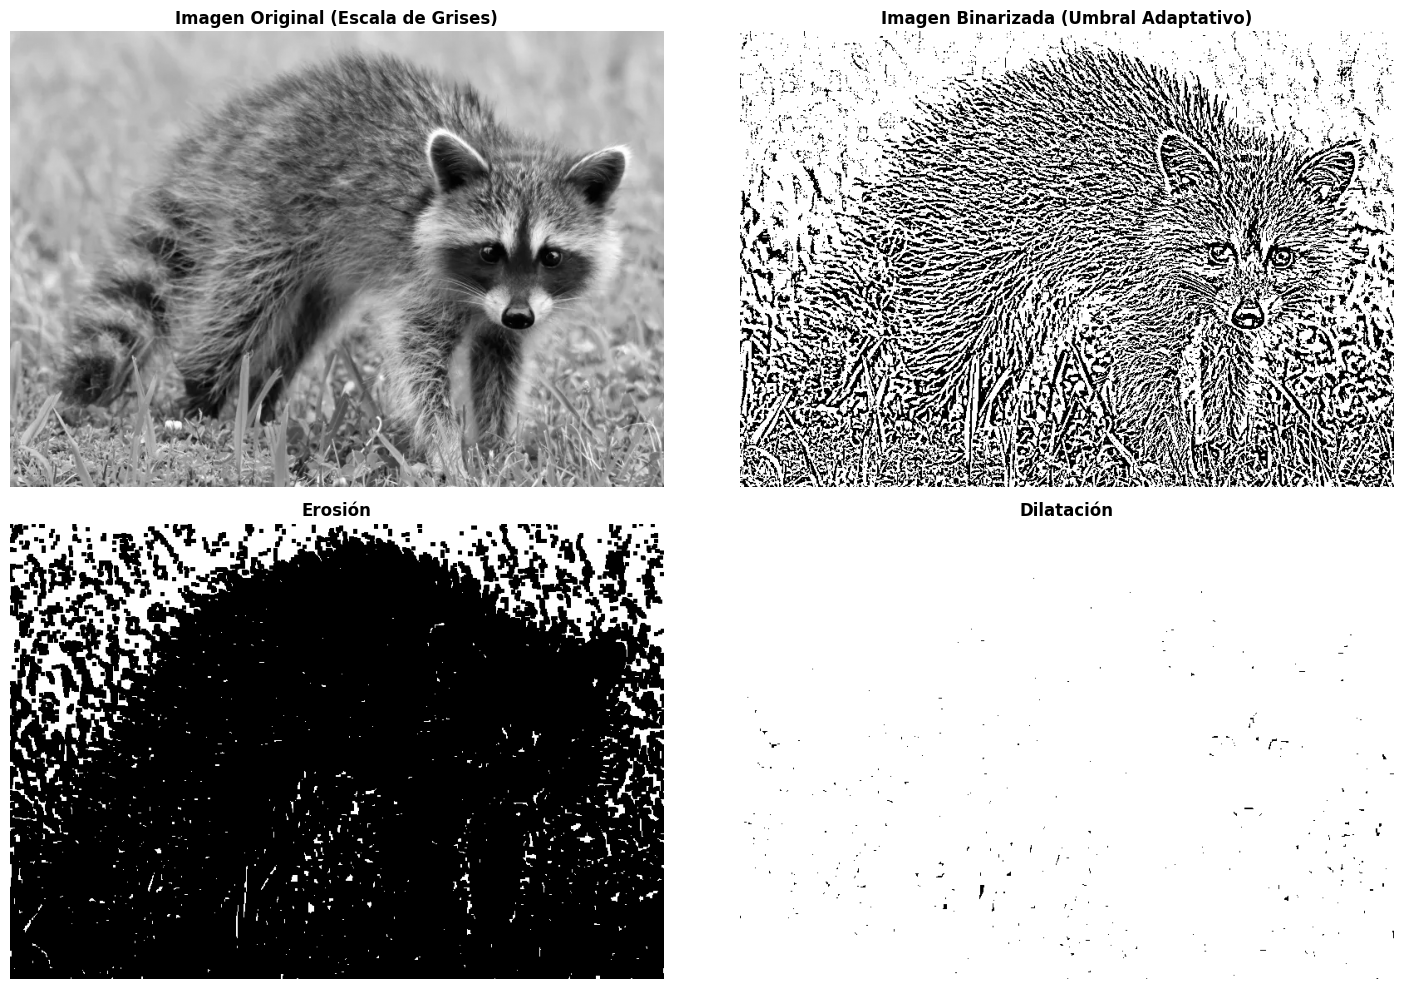


Efecto de las operaciones morfológicas:

Erosión:
- Reduce el tamaño de las regiones blancas (objetos).
- Elimina pequeños detalles y ruido.
- Los bordes de los objetos se contraen hacia adentro.
- Útil para separar objetos que están muy juntos.

Dilatación:
- Aumenta el tamaño de las regiones blancas (objetos).
- Rellena pequeños huecos y conecta regiones cercanas.
- Los bordes de los objetos se expanden hacia afuera.
- Útil para unir partes rotas de un mismo objeto.



In [9]:
# Convertir a escala de grises
gray_morph = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Binarizar la imagen usando umbral adaptativo para mejor resultado morfológico
# Usamos umbral adaptativo para manejar mejor las variaciones de iluminación
binary = cv2.adaptiveThreshold(gray_morph, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                cv2.THRESH_BINARY, 11, 2)

# Definir kernel para operaciones morfológicas
kernel = np.ones((5, 5), np.uint8)

# 4.1 Erosión
erosion = cv2.erode(binary, kernel, iterations=1)

# 4.2 Dilatación
dilation = cv2.dilate(binary, kernel, iterations=1)

# Visualizar resultados
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(gray_morph, cmap='gray')
plt.title('Imagen Original (Escala de Grises)', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(binary, cmap='gray')
plt.title('Imagen Binarizada (Umbral Adaptativo)', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(erosion, cmap='gray')
plt.title('Erosión', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(dilation, cmap='gray')
plt.title('Dilatación', fontsize=12, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

print("""
Efecto de las operaciones morfológicas:

Erosión:
- Reduce el tamaño de las regiones blancas (objetos).
- Elimina pequeños detalles y ruido.
- Los bordes de los objetos se contraen hacia adentro.
- Útil para separar objetos que están muy juntos.

Dilatación:
- Aumenta el tamaño de las regiones blancas (objetos).
- Rellena pequeños huecos y conecta regiones cercanas.
- Los bordes de los objetos se expanden hacia afuera.
- Útil para unir partes rotas de un mismo objeto.
""")


## 5. Animación GIF

Generamos un GIF animado que muestra secuencialmente:
1. Imagen original
2. Filtro de suavizado
3. Filtro de realce de bordes
4. Operaciones morfológicas (binarizada, erosión, dilatación)


In [ ]:
# Función para agregar texto a una imagen
def add_text_to_image(img, text, position='top'):
    """Agrega texto con fondo a una imagen"""
    img_with_text = img.copy()
    h, w = img_with_text.shape[:2]
    
    # Configurar fuente y tamaño
    font = cv2.FONT_HERSHEY_BOLD
    font_scale = 2.0
    thickness = 3
    color = (255, 255, 255)  # Blanco
    bg_color = (0, 0, 0)  # Negro
    
    # Obtener tamaño del texto
    (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, thickness)
    
    # Posición del texto
    if position == 'top':
        x = (w - text_width) // 2
        y = text_height + 40
    else:
        x = (w - text_width) // 2
        y = h - 40
    
    # Dibujar fondo (rectángulo negro semitransparente)
    padding = 20
    cv2.rectangle(img_with_text, 
                 (x - padding, y - text_height - padding), 
                 (x + text_width + padding, y + baseline + padding), 
                 bg_color, -1)
    
    # Dibujar texto
    cv2.putText(img_with_text, text, (x, y), font, font_scale, color, thickness)
    
    return img_with_text

# Preparar frames para el GIF con texto
frames = []

# Frame 1: Imagen original
frame1 = add_text_to_image(img_rgb, "1. IMAGEN ORIGINAL", 'top')
frames.append(frame1)

# Frame 2: Filtro de suavizado
frame2 = add_text_to_image(blurred, "2. FILTRO SUAVIZADO (Gaussian Blur)", 'top')
frames.append(frame2)

# Frame 3: Filtro de realce de bordes
frame3 = add_text_to_image(sharpened, "3. REALCE DE BORDES (Laplacian)", 'top')
frames.append(frame3)

# Frame 4: Imagen binarizada
binary_rgb = cv2.cvtColor(binary, cv2.COLOR_GRAY2RGB)
frame4 = add_text_to_image(binary_rgb, "4. BINARIZACION (Umbral Adaptativo)", 'top')
frames.append(frame4)

# Frame 5: Erosión
erosion_rgb = cv2.cvtColor(erosion, cv2.COLOR_GRAY2RGB)
frame5 = add_text_to_image(erosion_rgb, "5. EROSION", 'top')
frames.append(frame5)

# Frame 6: Dilatación
dilation_rgb = cv2.cvtColor(dilation, cv2.COLOR_GRAY2RGB)
frame6 = add_text_to_image(dilation_rgb, "6. DILATACION", 'top')
frames.append(frame6)

# Asegurar que todas las imágenes tengan el mismo tamaño
target_size = (img_rgb.shape[1], img_rgb.shape[0])
frames_resized = []
for frame in frames:
    if frame.shape[:2] != (target_size[1], target_size[0]):
        frame_resized = cv2.resize(frame, target_size)
        frames_resized.append(frame_resized)
    else:
        frames_resized.append(frame)

# Guardar GIF (duración: 4 segundos por frame para mejor lectura)
gif_path = 'gifs/examen_final_animacion.gif'
imageio.mimsave(gif_path, frames_resized, duration=4.0, loop=0)

print(f"GIF guardado en: {gif_path}")
print(f"Total de frames: {len(frames_resized)}")
print("El GIF muestra: Original → Suavizado → Realce de Bordes → Binarizada → Erosión → Dilatación")


GIF guardado en: gifs/examen_final_animacion.gif
Total de frames: 6
El GIF muestra: Original → Suavizado → Realce de Bordes → Binarizada → Erosión → Dilatación


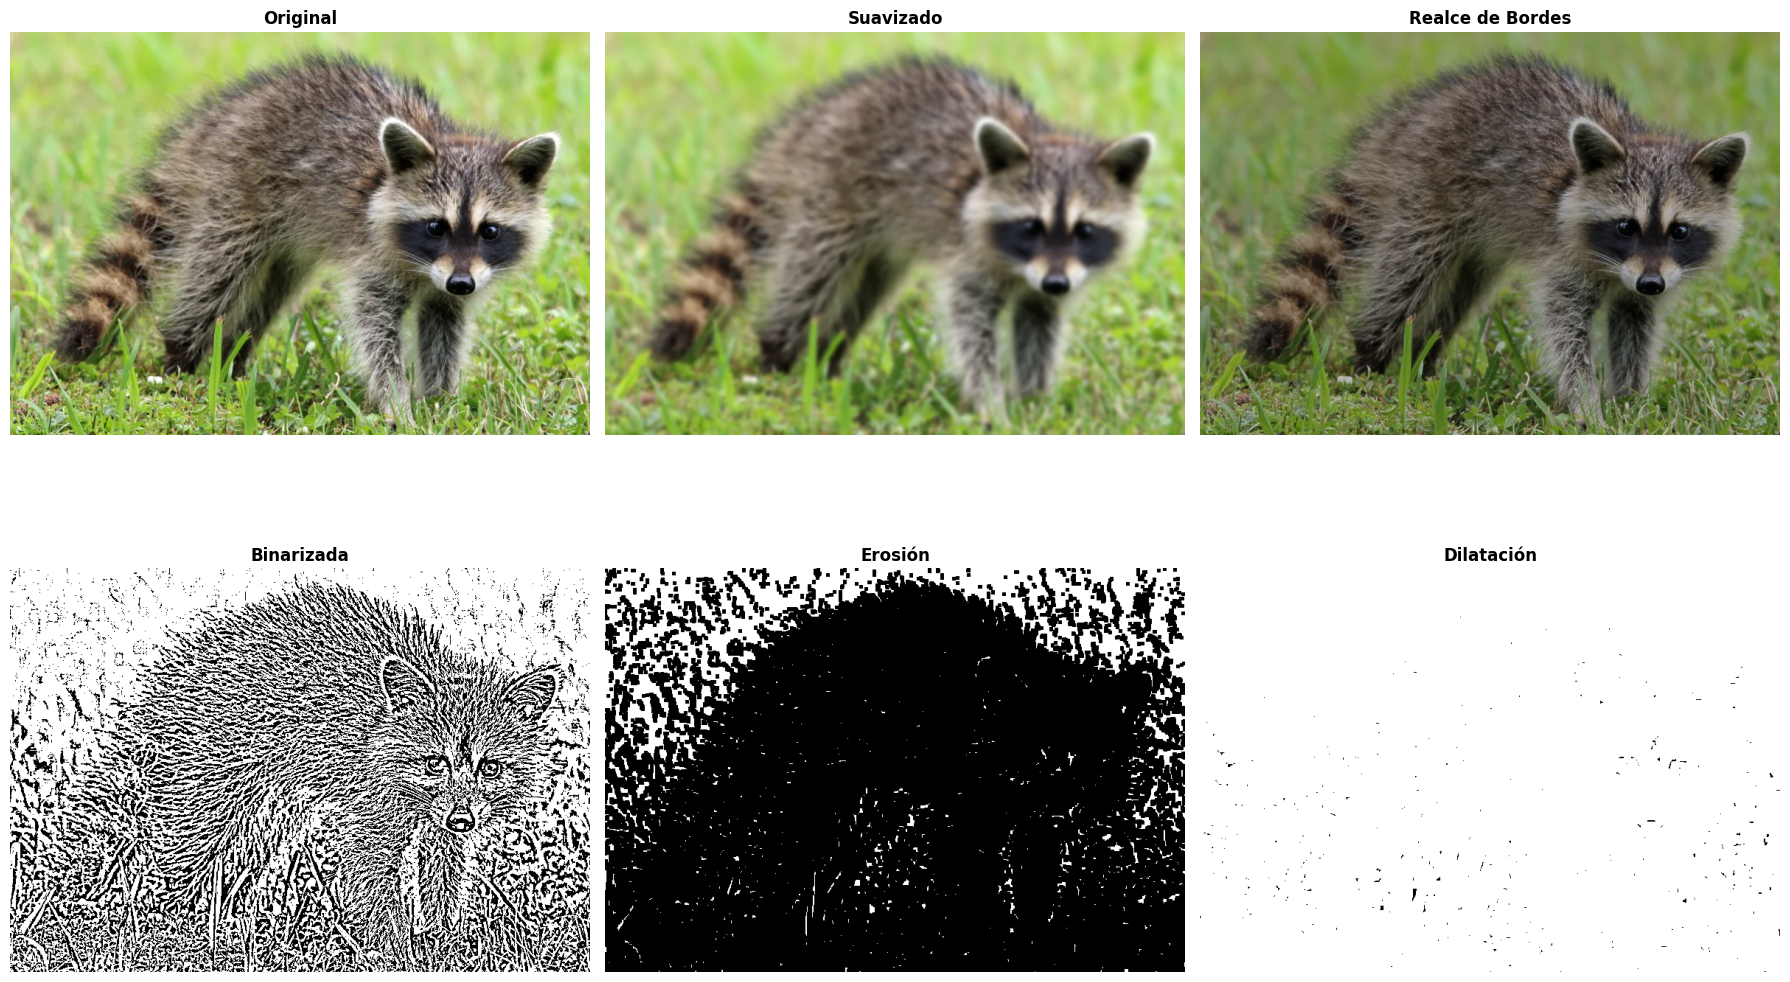

In [14]:
# Visualizar el GIF creado (mostrar los frames como referencia)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

titles = ['Original', 'Suavizado', 'Realce de Bordes', 'Binarizada', 'Erosión', 'Dilatación']

for i, (frame, title) in enumerate(zip(frames_resized, titles)):
    axes[i].imshow(frame)
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()
